In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

sys.path.append('../scripts')
from data_pipeline import load_and_prepare_data, load_single_channel, test_train_split
from feature_engineering import build_state_vector #, normalization (commenting normalizaiton out)
import plots, xgb_scripts, evaluate

## Single Cell Model

### State vector

In [2]:
df = load_single_channel(
    data_folder="../data/04-03-24",
    channel="A1",
)
df.head()

,mode,ox/red,error,control changes,Ns changes,counter inc.,Ns,I Range,time/s,control/V/mA,...,Q discharge/mA.h,Q charge/mA.h,Capacity/mA.h,Efficiency/%,control/V,control/mA,cycle number,P/W,R/Ohm,channel
340,1.0,0.0,0.0,0.0,0.0,1.0,3.0,112.0,11100.0,8000.0,...,0.0,0.00444,0.00444,0.0,0.0,8000.0,1.0,22.9,0.358,A1
341,1.0,1.0,0.0,0.0,1.0,1.0,3.0,112.0,11100.0,8000.0,...,0.0,0.00888,0.00888,0.0,0.0,8000.0,1.0,22.9,0.359,A1
342,1.0,1.0,0.0,0.0,0.0,1.0,3.0,112.0,11200.0,8000.0,...,0.0,133.00000,133.00000,0.0,0.0,8000.0,1.0,27.5,0.430,A1
343,1.0,1.0,0.0,0.0,0.0,1.0,3.0,112.0,11200.0,8000.0,...,0.0,200.00000,200.00000,0.0,0.0,8000.0,1.0,28.2,0.440,A1
344,1.0,1.0,0.0,0.0,0.0,1.0,3.0,112.0,11300.0,8000.0,...,0.0,267.00000,267.00000,0.0,0.0,8000.0,1.0,28.5,0.446,A1


In [3]:
def temporal_split_df(df):    
    all_cycles = sorted(df['cycle number'].unique())
    
    split_index = int(len(all_cycles) * 0.8)
    train_cycles = all_cycles[:split_index]
    test_cycles = all_cycles[split_index:]
    
    train_data = df[df['cycle number'].isin(train_cycles)]
    test_data = df[df['cycle number'].isin(test_cycles)]
    
    return train_data, test_data

df_train, df_test = temporal_split_df(df)

len(df_train), len(df_test)

(63442, 16134)

In [4]:
X_train, _ = build_state_vector(df_train)
X_test, _ = build_state_vector(df_test)

X_train, X_test

([array([ 1.79e-02,  1.78e-02,  1.77e-02,  1.77e-02,  1.76e-02,  1.75e-02,
          1.75e-02,  1.73e-02,  1.72e-02,  1.71e-02,  1.69e-02,  1.67e-02,
          1.64e-02,  1.62e-02,  1.59e-02,  1.56e-02,  1.52e-02,  1.48e-02,
          1.45e-02,  1.41e-02,  1.37e-02,  1.33e-02,  1.30e-02,  1.26e-02,
          1.23e-02,  1.21e-02,  1.19e-02,  1.17e-02,  1.17e-02,  1.17e-02,
          1.17e-02,  1.20e-02,  1.23e-02,  7.35e-04,  6.86e-04,  6.30e-04,
          6.04e-04,  6.06e-04,  6.36e-04,  6.91e-04,  7.65e-04,  8.51e-04,
          9.66e-04,  1.08e-03,  1.20e-03,  1.31e-03,  1.41e-03,  1.49e-03,
          1.56e-03,  1.61e-03,  1.63e-03,  1.61e-03,  1.54e-03,  1.40e-03,
          1.20e-03,  9.21e-04,  5.58e-04,  9.88e-05, -4.95e-04, -1.24e-03,
         -2.18e-03, -3.38e-03, -4.91e-03, -6.84e-03, -9.32e-03, -1.24e-02]),
  array([ 1.77e-02,  1.76e-02,  1.75e-02,  1.74e-02,  1.74e-02,  1.73e-02,
          1.72e-02,  1.71e-02,  1.70e-02,  1.68e-02,  1.66e-02,  1.64e-02,
          1.62e-02,  1.

In [5]:
X_train = np.array(X_train)
X_test = np.array(X_test)

X_train.shape, X_test.shape

((213, 66), (54, 66))

### Target Var

In [6]:
print(df_train['cycle number'].unique())

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168.
 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181. 182.
 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195. 196.
 197. 

In [7]:
y_train = df_train.groupby('cycle number')['Capacity/mA.h'].last().values
y_test = df_test.groupby('cycle number')['Capacity/mA.h'].last().values

y_train.shape, y_test.shape

((213,), (54,))

In [8]:
y_train, y_test

(array([4040., 4020., 4000., 3980., 3960., 3940., 3930., 3910., 3900.,
        3890., 3880., 3870., 3860., 3850., 3840., 3830., 3820., 3810.,
        3810., 3800., 3800., 3800., 3790., 3790., 3780., 3780., 3770.,
        3770., 3760., 3760., 3760., 3750., 3750., 3750., 3740., 3740.,
        3730., 3730., 3730., 3720., 3720., 3710., 3710., 3710., 3700.,
        3700., 3690., 3690., 3690., 3690., 3680., 3680., 3680., 3680.,
        3670., 3660., 3650., 3660., 3660., 3650., 3650., 3650., 3640.,
        3640., 3640., 3630., 3630., 3620., 3630., 3620., 3620., 3620.,
        3610., 3610., 3610., 3600., 3600., 3600., 3590., 3590., 3590.,
        3590., 3590., 3580., 3580., 3580., 3570., 3570., 3560., 3560.,
        3560., 3560., 3550., 3550., 3540., 3540., 3540., 3540., 3540.,
        3530., 3530., 3530., 3530., 3520., 3520., 3520., 3510., 3510.,
        3500., 3510., 3510., 3500., 3500., 3490., 3490., 3490., 3480.,
        3480., 3480., 3470., 3470., 3470., 3470., 3460., 3470., 3450.,
      

In [9]:
def scale_data(X_train, X_test, y_train, y_test):
    freq_mean = X_train.mean(axis=0)
    freq_std  = X_train.std(axis=0)
    X_train = (X_train - freq_mean) / freq_std
    X_test  = (X_test  - freq_mean) / freq_std

    y_train = y_train / y_train[0]
    y_test  = y_test / y_test[0]
    
    
    return X_train, X_test, y_train, y_test

In [10]:
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = scale_data(X_train, X_test, y_train, y_test)

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled

(array([[-0.84991233, -0.83345353, -0.81244243, ..., -1.4288677 ,
         -2.434389  , -2.20972745],
        [-0.93876206, -0.92728313, -0.9140872 , ..., -1.65839169,
         -2.434389  , -1.17528361],
        [-1.02761179, -1.02111273, -1.01573198, ..., -1.65839169,
         -2.434389  , -2.20972745],
        ...,
        [ 2.79292662,  2.73207124,  2.69430246, ...,  3.39113623,
          2.66346774,  1.92804791],
        [ 3.10390068,  3.06047484,  2.94841441, ...,  3.85018422,
          3.39173298,  2.96249175],
        [ 2.61522716,  2.54441204,  2.54183529, ...,  2.93208824,
          2.84553405,  0.89360407]], shape=(213, 66)),
 array([[2.88177635, 2.82590084, 2.79594724, ..., 3.39113623, 3.02760036,
         1.92804791],
        [2.65965202, 2.59132684, 2.59265768, ..., 2.70256424, 2.48140142,
         2.96249175],
        [2.79292662, 2.73207124, 2.69430246, ..., 3.16161223, 3.20966667,
         2.96249175],
        ...,
        [5.45841853, 5.31238522, 5.18459955, ..., 4.309

## Model

### Train Model

In [11]:
models = xgb_scripts.train_ensemble_model(X_train, y_train)

Training an ensemble of 10 models...


### Confirm Model Predictions

RMSE: 3.5523
R²: 0.9998
MSE: 12.6191
MAE: 2.1264
  Mean Prediction Uncertainty: 4.3895


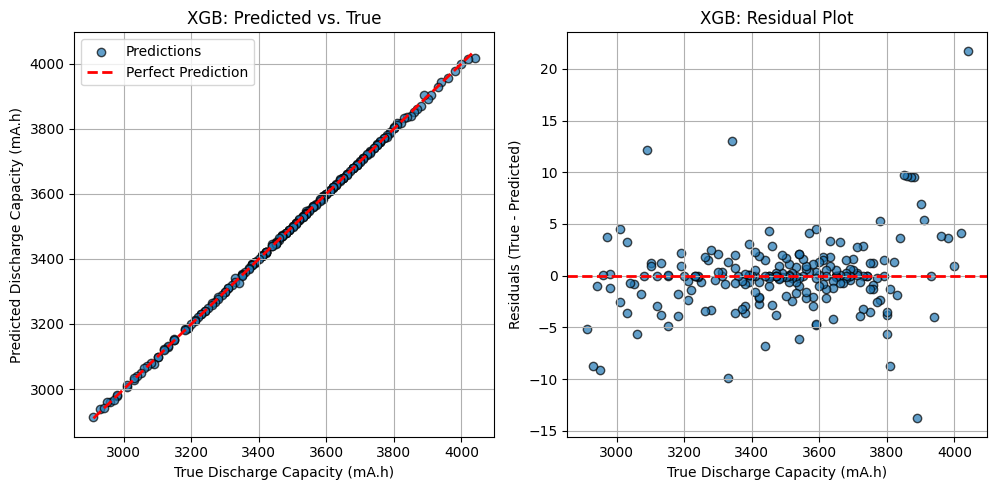

In [12]:
y_pred_mean, y_pred_std, all_predictions = xgb_scripts.predict_ensemble(models, X_train)

rmse, r2, mse, mae = evaluate.evaluate_model(y_train, y_pred_mean)
print(f"RMSE: {rmse:.4f}\nR²: {r2:.4f}\nMSE: {mse:.4f}\nMAE: {mae:.4f}")
prediction_fig = plots.model_predictions(y_train.flatten(), y_pred_mean, y_pred_std, title_prefix="XGB")

plt.show()

### New Data

RMSE: 367.1798
R²: -2.4841
MSE: 134821.0281
MAE: 306.4781
  Mean Prediction Uncertainty: 8.1942


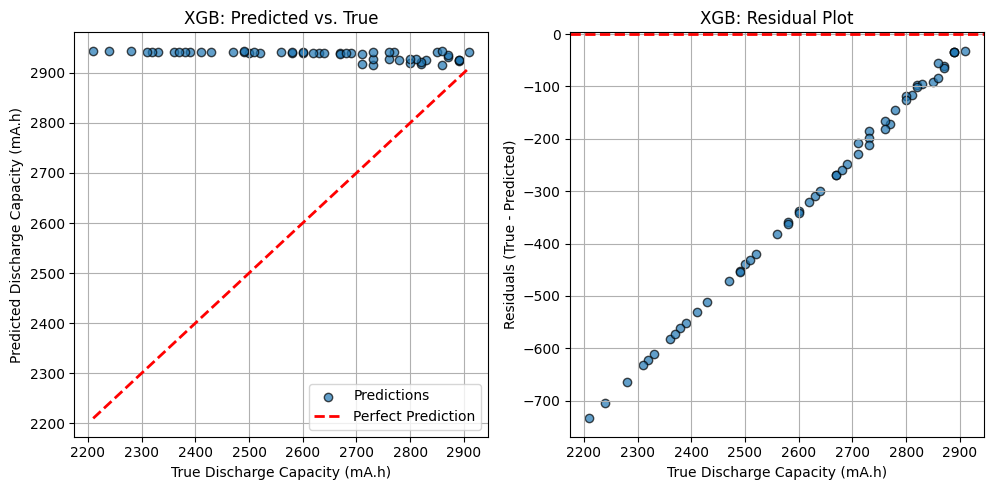

In [13]:
y_pred_mean, y_pred_std, all_predictions = xgb_scripts.predict_ensemble(models, X_test)

rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred_mean)
print(f"RMSE: {rmse:.4f}\nR²: {r2:.4f}\nMSE: {mse:.4f}\nMAE: {mae:.4f}")
prediction_fig = plots.model_predictions(y_test.flatten(), y_pred_mean, y_pred_std, title_prefix="XGB")

plt.show()

In [14]:
print("✅ Notebook ran to completion without errors!")


✅ Notebook ran to completion without errors!
